# 基于真实天光数据的自然光光谱估计与室内照明补偿设计

本项目使用公开实测天光光谱数据（SKYSPECTRA），结合天气、时间、地点、太阳位置等低成本环境特征，训练机器学习模型估计自然光相对光谱，并进一步用于室内照明补偿设计。

整条链路是：

> 环境特征 → 模型预测 PCA 主成分系数 → PCA 逆变换 → 380nm-780nm 自然光相对光谱 → 与目标光谱对比 → LED 通道补偿比例 → 补偿前后误差

本项目不试图完整解决真实建筑照明中的复杂问题，而是从课程设计角度出发，验证"低成本环境特征 → 自然光光谱估计 → 照明补偿"这条流程的可行性。

## 1. 数据来源与下载

本项目使用三类公开真实数据，全部由 Python 代码联网获取并在本地缓存：

| 数据 | 来源 | 用途 |
| --- | --- | --- |
| 实测天光光谱及元数据 | SKYSPECTRA 数据集（Zenodo record 8147546） | 光谱标签、地点、时间、太阳位置、室外照度、天空状况 |
| 历史小时天气 | Open-Meteo Historical Weather API | 云量、湿度、温度、降水特征 |
| 实测 LED 光谱 | Harald Brendel 公开 LED SPD 数据 | 照明补偿用的七通道 LED 光谱 |

需要说明：天气数据是按地点和时间对齐的历史天气特征，不等同于现场同步气象测量，可能与测量瞬间的天气存在差异。

下面先确认原始文件就绪（已下载过则直接使用缓存），本节不做任何模型训练。

In [1]:
from src.real_data_pipeline import ensure_raw_files, build_dataset, OUTPUT_PATH

# 下载（或复用缓存）全部原始文件，并列出文件清单
raw_summary = ensure_raw_files()
display(raw_summary)

# 若最终数据集不存在，执行清洗、合并、天气对齐流程
if not OUTPUT_PATH.exists():
    build_dataset()
else:
    print(f"数据集已存在：{OUTPUT_PATH.name}，直接使用。")

[缓存] meta_location.csv 已存在，跳过下载。
[缓存] meta_weather.csv 已存在，跳过下载。
[缓存] meta_sun_positions.csv 已存在，跳过下载。
[缓存] meta_measurement_parameters.csv 已存在，跳过下载。
[缓存] spectral_horizontal_irradiance.csv 已存在，跳过下载。


,文件名,大小/MB,数据行数,列数
0,meta_location.csv,0.00,5,9
1,meta_weather.csv,0.37,8377,7
2,meta_sun_positions.csv,0.39,8377,6
3,meta_measurement_parameters.csv,0.00,6,10
4,spectral_horizontal_irradiance.csv,74.84,1466568,7


数据集已存在：real_spectrum_weather_dataset.csv，直接使用。


In [2]:
from src.data_loader import load_dataset, dataset_summary

dataset = load_dataset()
print(f"最终数据集：{dataset.shape[0]} 行 × {dataset.shape[1]} 列")

最终数据集：5664 行 × 58 列


## 2. 数据观察与预处理

先观察数据基本情况：字段构成、缺失值、站点分布和时间范围。

数据清洗在数据流水线中完成，主要包括：去掉光谱缺失值和负值、过滤全 0 光谱、把原始 1nm 步长光谱线性插值重采样到 380-780nm 每 10nm 一点（41 维）、删除特征缺失的样本。

In [3]:
display(dataset.head())
print("形状:", dataset.shape)
print("\n字段列表:")
print(list(dataset.columns[:17]), "...")
print(f"光谱字段: wavelength_380 ~ wavelength_780，共 {sum(c.startswith('wavelength_') for c in dataset.columns)} 列")

,sample_id,date,hour,month,location_code,station_name,latitude,longitude,weather,sky_condition,...,wavelength_690,wavelength_700,wavelength_710,wavelength_720,wavelength_730,wavelength_740,wavelength_750,wavelength_760,wavelength_770,wavelength_780
0,1,2016-03-16,8,3,FR-VLX,Vaulx-en-Velin,45.78,4.93,阴,overcast,...,0.04569,0.05133,0.05133,0.05133,0.05133,0.05133,0.05133,0.05133,0.05133,0.05133
1,2,2016-03-16,8,3,FR-VLX,Vaulx-en-Velin,45.78,4.93,阴,overcast,...,0.04899,0.05530,0.05530,0.05530,0.05530,0.05530,0.05530,0.05530,0.05530,0.05530
2,3,2016-03-16,8,3,FR-VLX,Vaulx-en-Velin,45.78,4.93,阴,overcast,...,0.05205,0.05873,0.05873,0.05873,0.05873,0.05873,0.05873,0.05873,0.05873,0.05873
3,4,2016-03-16,8,3,FR-VLX,Vaulx-en-Velin,45.78,4.93,阴,overcast,...,0.05506,0.06235,0.06235,0.06235,0.06235,0.06235,0.06235,0.06235,0.06235,0.06235
4,5,2016-03-16,8,3,FR-VLX,Vaulx-en-Velin,45.78,4.93,阴,overcast,...,0.05803,0.06566,0.06566,0.06566,0.06566,0.06566,0.06566,0.06566,0.06566,0.06566


形状: (5664, 58)

字段列表:
['sample_id', 'date', 'hour', 'month', 'location_code', 'station_name', 'latitude', 'longitude', 'weather', 'sky_condition', 'cloud_cover', 'humidity', 'temperature', 'precipitation', 'solar_altitude', 'solar_azimuth', 'outdoor_lux'] ...
光谱字段: wavelength_380 ~ wavelength_780，共 41 列


In [4]:
display(dataset_summary(dataset))

print("缺失值总数:", int(dataset.isna().sum().sum()))
print("\n各站点样本数:")
print(dataset["station_name"].value_counts().to_string())
print("\n天气类别分布:")
print(dataset["weather"].value_counts().to_string())

,项目,数值
0,样本数,5664
1,字段数,58
2,光谱维度,41
3,波长范围,380nm-780nm（每 10nm 一点）
4,观测站数,2
5,观测站,Singapore / Vaulx-en-Velin
6,时间范围,2016-03-16 至 2018-07-28
7,小时范围,7 时至 19 时


缺失值总数: 0

各站点样本数:
station_name
Vaulx-en-Velin    5636
Singapore           28

天气类别分布:
weather
晴     3156
雨     1657
阴      514
多云     337


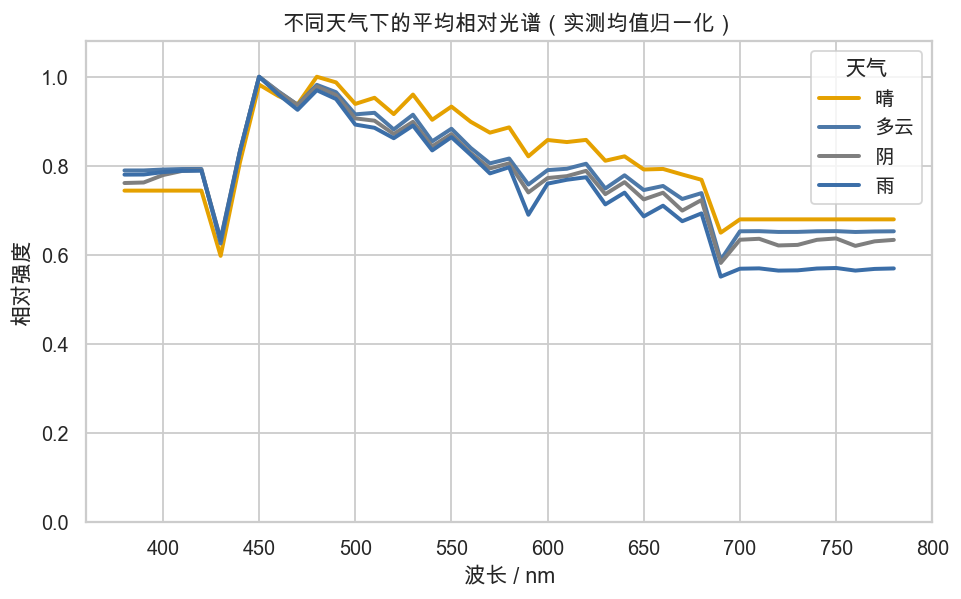

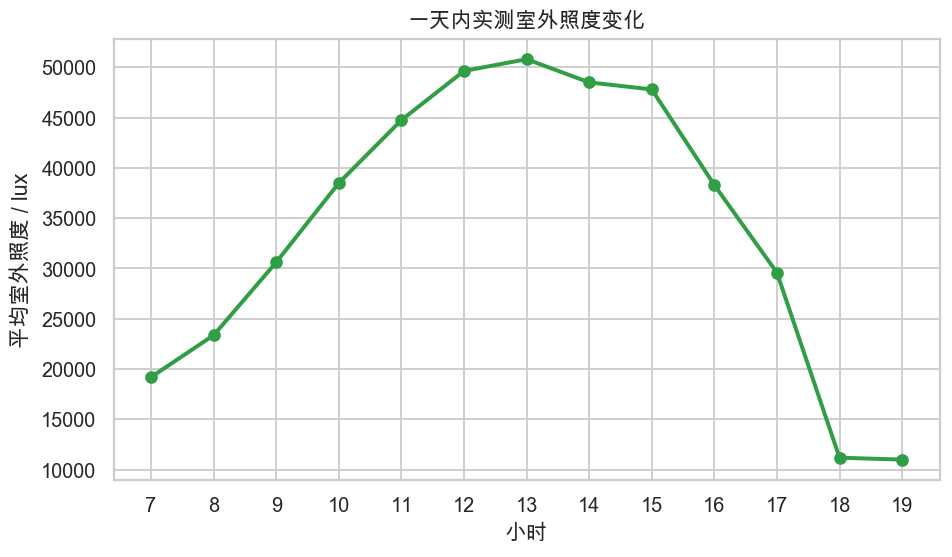

In [5]:
import matplotlib.pyplot as plt
from src.visualization import plot_weather_spectrum_compare, plot_hourly_lux

# 不同天气下的平均相对光谱：环境条件确实会改变光谱形状，预测才有意义
plot_weather_spectrum_compare(dataset)
plt.show()

plot_hourly_lux(dataset)
plt.show()

## 3. 特征工程与光谱 PCA

**模型输入**（低成本环境特征，共 12 个原始字段）：

- 时间特征：`hour`、`month`
- 太阳位置：`solar_altitude`、`solar_azimuth`
- 天气特征：`cloud_cover`、`humidity`、`temperature`、`precipitation`
- 观测辅助：`outdoor_lux`（水平照度）
- 类别特征：`weather`、`sky_condition`、`location_code`（独热编码）

**模型输出（目标）**：41 维相对光谱。每条实测光谱除以自身最大值归一化到 0-1，模型只学习光谱形状，照度高低由 `outdoor_lux` 等特征单独表达。

预处理统一放进 sklearn 的 `ColumnTransformer`：数值特征标准化（KNN、MLP、线性模型都依赖），类别特征独热编码。

In [6]:
from src.preprocessing import (
    NUMERIC_FEATURES, CATEGORICAL_FEATURES, FEATURE_COLUMNS,
    extract_features_targets, split_dataset, build_preprocessor,
)

print("数值特征:", NUMERIC_FEATURES)
print("类别特征:", CATEGORICAL_FEATURES)

x, y = extract_features_targets(dataset)
print(f"\n特征表 X: {x.shape}，相对光谱目标 Y: {y.shape}")
display(x.head())
print("独热编码后的特征维度:", build_preprocessor().fit_transform(x).shape[1])

数值特征: ['hour', 'month', 'solar_altitude', 'solar_azimuth', 'cloud_cover', 'humidity', 'temperature', 'precipitation', 'outdoor_lux']
类别特征: ['weather', 'sky_condition', 'location_code']

特征表 X: (5664, 12)，相对光谱目标 Y: (5664, 41)


,hour,month,solar_altitude,solar_azimuth,cloud_cover,humidity,temperature,precipitation,outdoor_lux,weather,sky_condition,location_code
0,8,3,15.1,108.4,0.81,0.84,2.1,0.0,5035.0,阴,overcast,FR-VLX
1,8,3,15.2,108.6,0.81,0.84,2.1,0.0,5324.0,阴,overcast,FR-VLX
2,8,3,15.4,108.8,0.81,0.84,2.1,0.0,5658.0,阴,overcast,FR-VLX
3,8,3,15.6,109.0,0.81,0.84,2.1,0.0,5963.0,阴,overcast,FR-VLX
4,8,3,15.7,109.2,0.81,0.84,2.1,0.0,6252.0,阴,overcast,FR-VLX


独热编码后的特征维度: 18


光谱相邻波长高度相关，直接预测 41 维既慢又难解释。先用 10 个主成分观察解释方差，再决定保留多少个。

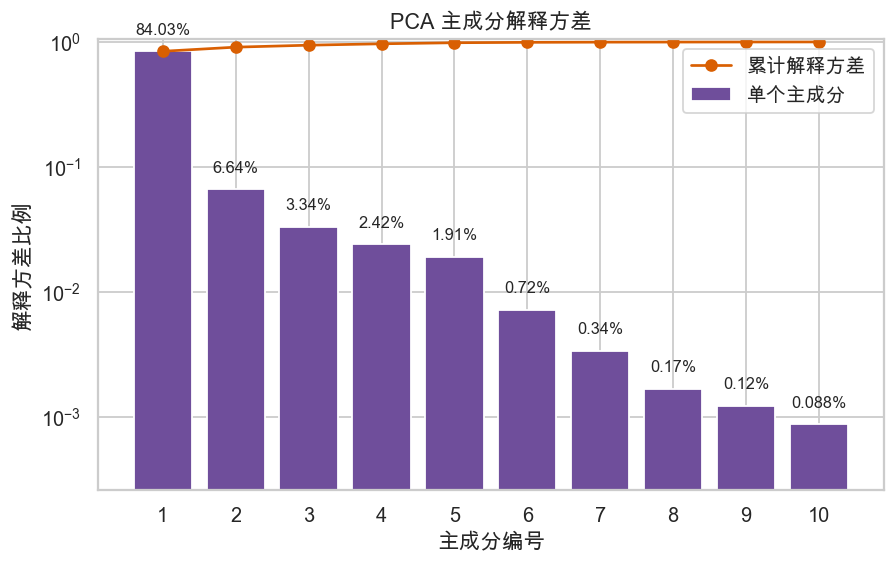

,主成分,解释方差比例,累计解释方差
0,1,0.840319,0.840319
1,2,0.066369,0.906688
2,3,0.033432,0.940120
3,4,0.024193,0.964313
4,5,0.019139,0.983452
5,6,0.007226,0.990679
6,7,0.003391,0.994070
7,8,0.001696,0.995766
8,9,0.001243,0.997008
9,10,0.000882,0.997890


In [7]:
from src.spectrum_pca import SpectrumPCA
from src.visualization import plot_pca_variance

# 先用 10 个主成分观察解释方差衰减情况
pca_probe = SpectrumPCA(n_components=10)
pca_probe.fit_transform(y)
plot_pca_variance(pca_probe.pca)
plt.show()
display(pca_probe.variance_frame())

前 5 个主成分累计解释方差约 98%，之后每个主成分的贡献都低于 1%。继续增加主成分对还原精度帮助很小，反而增加模型输出维度，因此正式实验保留 **5 个主成分**。

In [8]:
N_COMPONENTS = 5
spectrum_pca = SpectrumPCA(n_components=N_COMPONENTS)
y_pca = spectrum_pca.fit_transform(y)
print(f"PCA 降维: {y.shape[1]} 维光谱 → {y_pca.shape[1]} 个主成分系数")
print(f"累计解释方差: {spectrum_pca.explained_variance_ratio_.sum():.4f}")

# 划分训练集/测试集（按天气类别分层）
x_train, x_test, y_train_pca, y_test_pca, idx_train, idx_test = split_dataset(x, y_pca)
y_test_spectrum = y[idx_test]   # 测试集真实相对光谱（用于在光谱空间统一评价）
print(f"训练集 {len(x_train)} 条，测试集 {len(x_test)} 条")

PCA 降维: 41 维光谱 → 5 个主成分系数
累计解释方差: 0.9835
训练集 4531 条，测试集 1133 条


## 4. 模型训练

五个 sklearn 回归模型在**相同的训练集、特征、PCA 目标**下逐一训练：

1. Linear Regression —— 线性基准
2. KNN Regressor —— 相似环境样本投票
3. Decision Tree Regressor —— 非线性、结构可解释
4. Random Forest Regressor —— 多树集成，稳定性好
5. MLP Regressor —— 神经网络，`hidden_layer_sizes=(128, 64)`、`max_iter=600`、`early_stopping=True`，控制规模保证课程环境下能稳定训完

每个模型记录训练时间和预测时间，结果不预设、由真实指标决定。

In [9]:
from src.model_training import train_all_models

trained = train_all_models(x_train, y_train_pca, x_test, spectrum_pca)

[训练] Linear Regression ... 

完成，训练 0.02s，预测 0.0025s
[训练] KNN ... 

完成，训练 0.01s，预测 0.0350s
[训练] Decision Tree ... 

完成，训练 0.02s，预测 0.0024s
[训练] Random Forest ... 

完成，训练 0.28s，预测 0.0156s
[训练] MLP ... 

完成，训练 1.32s，预测 0.0034s


## 5. 模型评估与最优模型选择

所有模型的预测结果先经 PCA 逆变换还原回 41 维光谱空间，再统一计算 MAE、RMSE、R²，连同训练/预测时间一起对比。

,model,MAE,RMSE,R2,train_time_s,predict_time_s
0,Random Forest,0.005059,0.008633,0.959311,0.284,0.0156
1,KNN,0.005017,0.008985,0.954194,0.005,0.0350
2,MLP,0.005816,0.009481,0.962482,1.318,0.0034
3,Decision Tree,0.005366,0.012354,0.870210,0.017,0.0024
4,Linear Regression,0.022545,0.037550,0.635306,0.017,0.0025


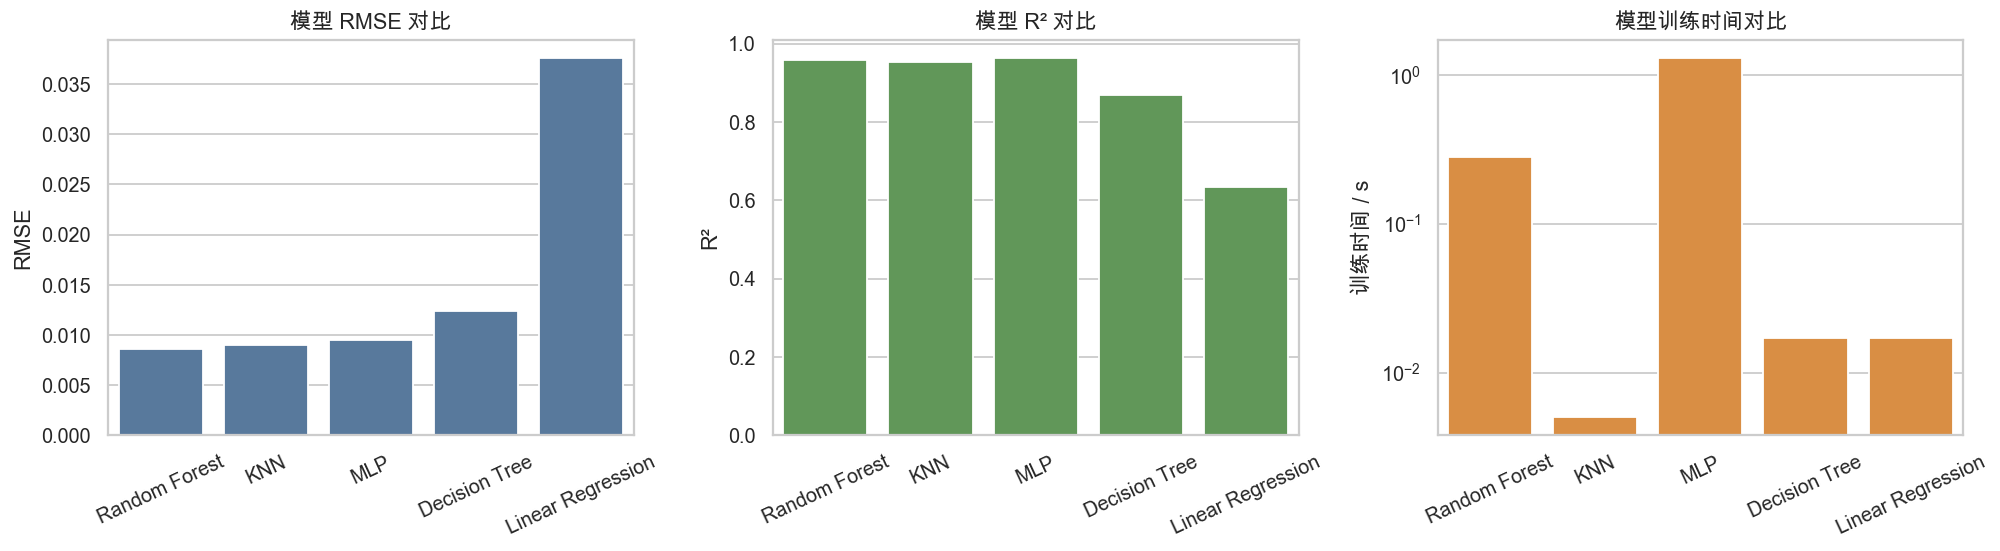

最佳模型（RMSE 最小）: Random Forest


In [10]:
from src.evaluation import build_metrics_table, select_best_model
from src.visualization import plot_model_compare

metrics = build_metrics_table(trained, y_test_spectrum)
display(metrics)

plot_model_compare(metrics)
plt.show()

best_name = select_best_model(metrics)
print(f"最佳模型（RMSE 最小）: {best_name}")

从结果看，随机森林在 RMSE、MAE 上最优，KNN 紧随其后；MLP 的 R² 略高，但 RMSE 和 MAE 不如随机森林——MLP 具有非线性拟合能力，但对标准化、参数设置和数据规模较敏感，在本项目数据条件下随机森林表现更稳定。决策树单树波动较大，线性回归明显落后，说明环境特征与光谱形状之间不是简单线性关系。综合精度与稳定性，选择**随机森林**作为最终模型。

随机森林还能输出特征重要性，帮助理解模型主要依赖哪些环境因素：

,feature,importance
0,outdoor_lux,0.542308
1,cloud_cover,0.086140
2,solar_azimuth,0.061026
3,weather,0.056703
4,solar_altitude,0.048230
5,hour,0.044855
6,month,0.044826
7,sky_condition,0.034435
8,temperature,0.034163
9,humidity,0.032849


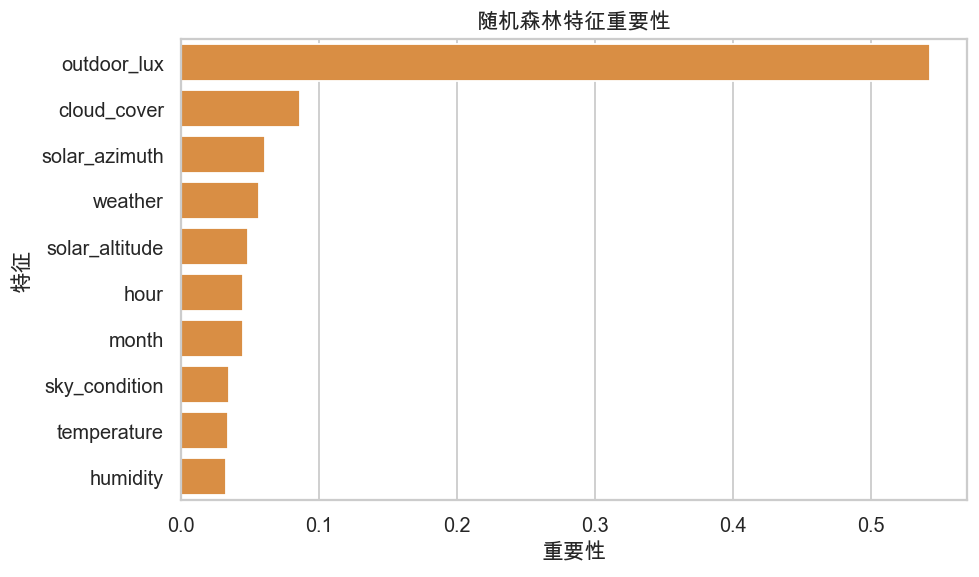

In [11]:
from src.model_training import feature_importance_frame
from src.visualization import plot_feature_importance

feature_importance = feature_importance_frame(trained["Random Forest"])
display(feature_importance)
plot_feature_importance(feature_importance)
plt.show()

## 6. 光谱预测与还原

从测试集取一条样本，对比实测相对光谱与模型还原的预测光谱。预测流程：环境特征 → 最佳模型输出 5 个 PCA 系数 → `inverse_transform` 还原 41 维光谱。

样本环境特征：


,hour,month,solar_altitude,solar_azimuth,cloud_cover,humidity,temperature,precipitation,outdoor_lux,weather,sky_condition,location_code
5260,16,9,29.3,229.2,0.0,0.37,25.9,0.0,47400.0,晴,clear,FR-VLX


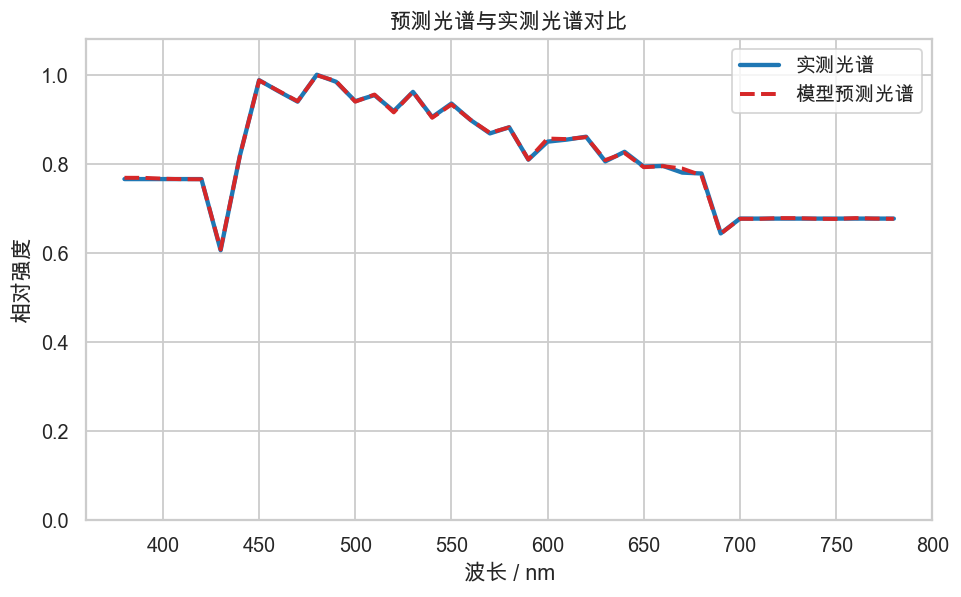

该样本误差：


,指标,数值
0,MAE,0.00149
1,RMSE,0.00230


In [12]:
from src.evaluation import sample_error_frame
from src.visualization import plot_prediction_compare

sample_position = 0
true_spectrum = y_test_spectrum[sample_position]
pred_spectrum = trained[best_name].y_pred_spectrum[sample_position]

# 该样本对应的环境输入
print("样本环境特征：")
display(x_test.iloc[[sample_position]])

plot_prediction_compare(true_spectrum, pred_spectrum)
plt.show()

print("该样本误差：")
display(sample_error_frame(true_spectrum, pred_spectrum))

## 7. 照明补偿应用展示

本节是应用层演示：用户设定一组天气/环境参数，系统走完整条应用链路——

> 场景参数 → 模型预测 PCA 主成分系数 → 逆变换还原自然光相对光谱 → 多通道 LED 补偿 → 传统双色温 LED 对照 → 光谱与色度对比

涉及的应用层算法：

- **目标光谱**：实测晴天高太阳高度角日光的平均相对光谱（由真实数据计算，不是人工设定曲线）；
- **当前光谱**：模型预测的自然光相对光谱 × 室内自然光占比（由室外照度和目标照度估算）；
- **多通道补偿**：非负最小二乘求解七个 LED 通道比例，使 `自然光 + LED 混光` 尽量接近目标光谱；
- **传统双色温对照**：常见双色温灯具只有冷暖配比和亮度两个旋钮，把混光写成 `gain × (a×暖白 + (1-a)×冷白)`，在 a∈[0,1] 上搜索与目标误差最小的组合，用来说明"能调冷暖，但光谱形状受限"；
- **近似色度预览**：光谱与 CIE 2015（CIE 2006 生理学数据推导）10° 观察者色匹配函数积分得 XYZ，亮度归一化后转 sRGB，刻意不使用 1931 年的旧标准观察者。

四个天气预设不是手写参数：每个预设先在真实数据集中筛出对应场景子集，数值特征取中位数、类别特征取众数，保证输入和训练数据同分布。

In [13]:
from src.led_spectrum_data import fetch_and_build_dual_white_spectrum
from src.model_training import SpectrumPredictor
from src.preprocessing import FEATURE_COLUMNS
from src.application_demo import (
    PRESET_DEFINITIONS, PRESET_NAMES, run_application_demo,
    pca_coefficient_frame, channel_percent_frame,
    error_comparison_frame, color_preview_frame, preset_summary_frame,
)

# 确保实测 LED 光谱就绪（已缓存则直接复用）
fetch_and_build_dual_white_spectrum(force=False)

# 把第 4-5 节训练好的最佳模型包装成预测器，供应用层调用
predictor = SpectrumPredictor(
    best_model_name=best_name,
    pipeline=trained[best_name].pipeline,
    spectrum_pca=spectrum_pca,
    feature_columns=FEATURE_COLUMNS,
    metrics=metrics,
)

print("可选天气预设：")
for name in PRESET_NAMES:
    print(f"  - {name}：{PRESET_DEFINITIONS[name]['说明']}")

PRESET = "晴天中午"   # 课堂演示时改这里即可切换场景
demo = run_application_demo(predictor, dataset, preset=PRESET, scene="学习", target_lux=500.0)

print(f"\n当前预设「{PRESET}」生成的模型输入：")
display(demo.features)

可选天气预设：
  - 晴天中午：晴天、接近正午、太阳高度角较高
  - 多云下午：云量中等的下午
  - 阴雨天气：高云量、有降水
  - 傍晚低太阳高度角：接近日落、太阳高度角低、光谱偏暖



当前预设「晴天中午」生成的模型输入：


,hour,month,solar_altitude,solar_azimuth,cloud_cover,humidity,temperature,precipitation,outdoor_lux,weather,sky_condition,location_code
0,12,6.0,41.6,175.2,0.0,0.55,24.1,0.0,70100.0,晴,clear,FR-VLX


模型预测的 5 个 PCA 主成分系数：


,主成分,预测系数
0,PC1,3.8234
1,PC2,0.4505
2,PC3,0.0146
3,PC4,-0.6616
4,PC5,-0.3331


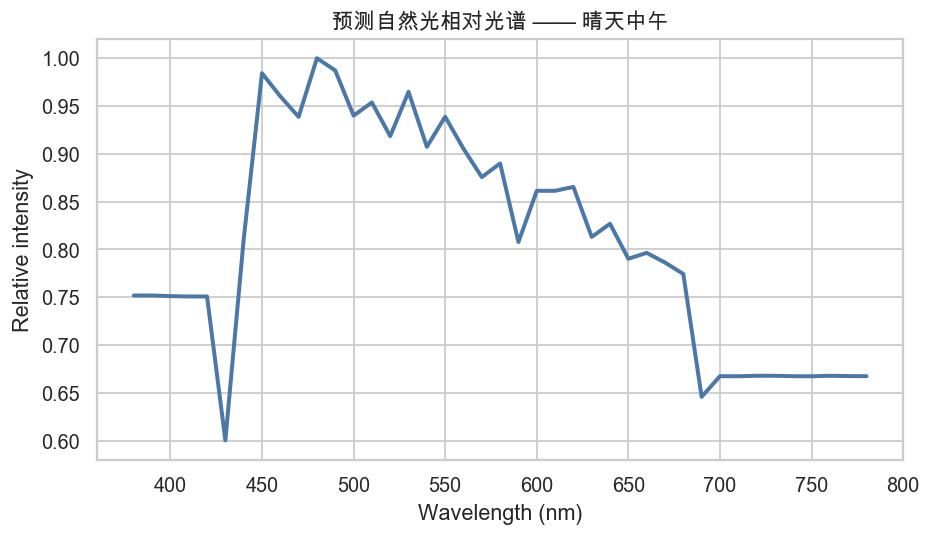

In [14]:
from src.spectrum_utils import WAVELENGTHS

print("模型预测的 5 个 PCA 主成分系数：")
display(pca_coefficient_frame(demo))

# 逆变换还原的预测自然光相对光谱
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(WAVELENGTHS, demo.predicted_spectrum, color="#4c78a8", linewidth=2.2)
ax.set_title(f"预测自然光相对光谱 —— {PRESET}")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Relative intensity")
plt.show()

In [15]:
# 多通道 LED 补偿：非负最小二乘解出的七通道驱动比例
print("多通道 LED 补偿比例：")
display(channel_percent_frame(demo))

# 传统双色温对照：冷暖配比 + 亮度两个旋钮下的最优组合
print(f"传统双色温对照方案：{demo.dual_cct_label}，亮度系数 {demo.dual_cct.gain:.3f}")

多通道 LED 补偿比例：


,通道,驱动比例,占比
0,深蓝/蓝光,0.3360,24.2%
1,青光,0.4186,30.2%
2,绿光,0.1059,7.6%
3,琥珀光,0.0040,0.3%
4,红光,0.0044,0.3%
5,暖白,0.4432,32.0%
6,冷白,0.0746,5.4%


传统双色温对照方案：暖白 43% / 冷白 57%，亮度系数 0.876


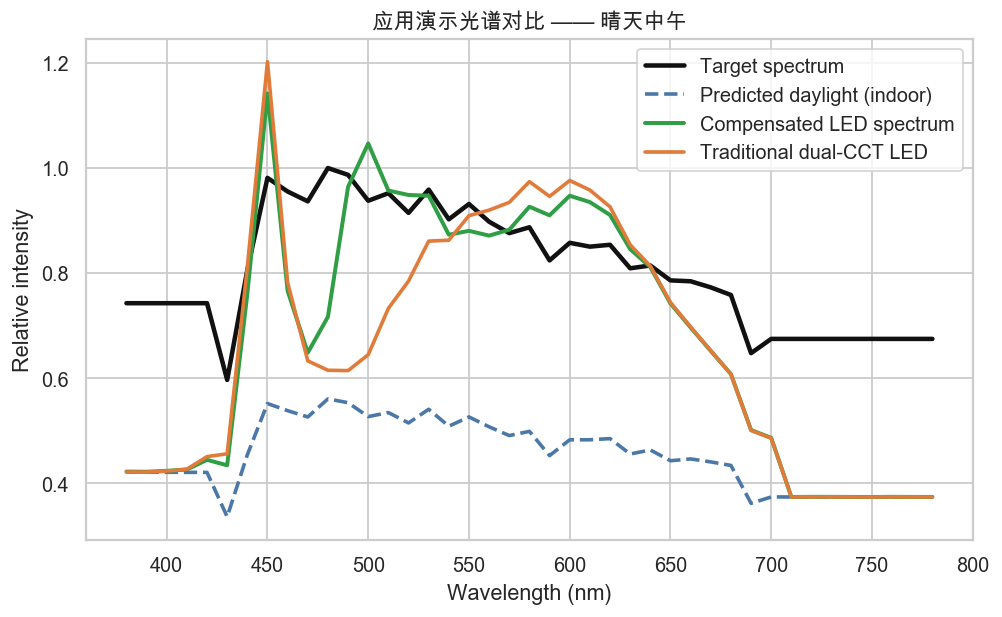

In [16]:
from src.visualization import plot_application_spectra, plot_color_circles

# 四条光谱曲线：目标 / 预测自然光室内贡献 / 多通道补偿后 / 传统双色温
plot_application_spectra(demo)
plt.show()

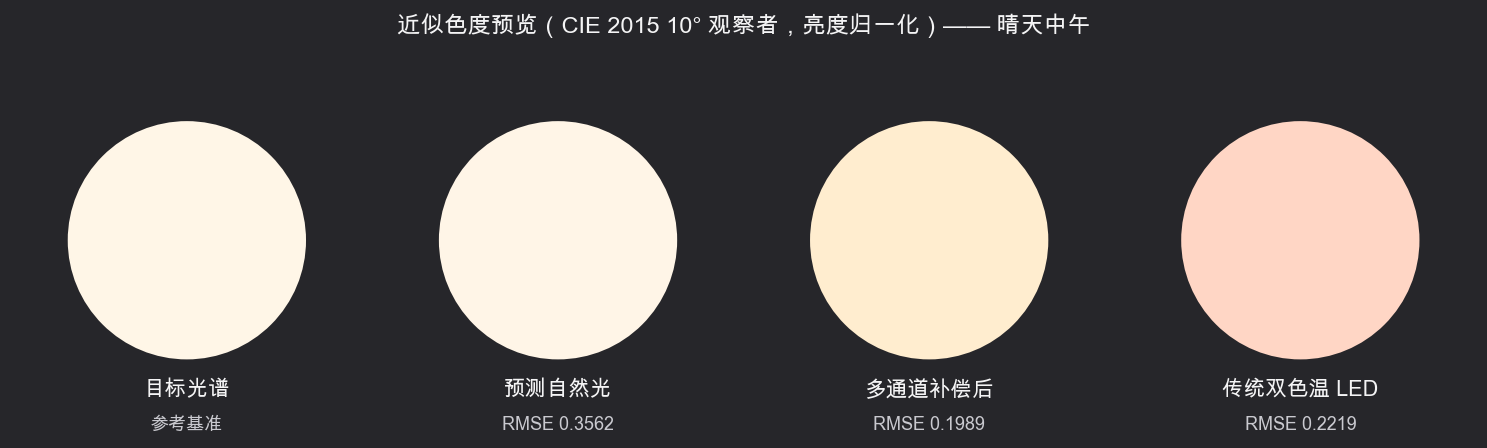

,光状态,近似显示色,说明
0,目标光谱,#FFF6E7,参考基准
1,预测自然光,#FFF5E7,RMSE 0.3562
2,多通道补偿后,#FFEDCF,RMSE 0.1989
3,传统双色温 LED,#FFD6C5,RMSE 0.2219


说明：屏幕颜色仅为根据光谱计算得到的近似色度预览，不能替代真实光谱视觉效果。不同光谱可能在屏幕上显示为相近颜色，但其光谱组成仍然不同。


In [17]:
# 白圆近似色度对比：亮度统一归一化，只看色度差异
plot_color_circles(demo)
plt.show()

display(color_preview_frame(demo))
print("说明：屏幕颜色仅为根据光谱计算得到的近似色度预览，不能替代真实光谱视觉效果。"
      "不同光谱可能在屏幕上显示为相近颜色，但其光谱组成仍然不同。")

In [18]:
# 三种方案相对目标光谱的误差
display(error_comparison_frame(demo))

# 四个天气预设各跑一遍的汇总
print("四个天气预设的补偿效果汇总：")
display(preset_summary_frame(predictor, dataset))

,方案,RMSE,MAE,相对未补偿误差下降
0,未补偿（仅室内自然光）,0.3562,0.3530,0.0%
1,多通道 LED 补偿后,0.1989,0.1594,44.2%
2,传统双色温 LED（暖白 43% / 冷白 57%）,0.2219,0.1889,37.7%


四个天气预设的补偿效果汇总：


,天气预设,未补偿RMSE,多通道补偿RMSE,双色温对照RMSE,多通道误差下降,双色温暖白占比
0,晴天中午,0.3562,0.1989,0.2219,44.2%,43%
1,多云下午,0.6080,0.3342,0.3737,45.0%,45%
2,阴雨天气,0.7424,0.4126,0.4603,44.4%,44%
3,傍晚低太阳高度角,0.7500,0.4161,0.4640,44.5%,45%


从误差表可以看到：多通道补偿在四个天气预设下都把误差降低 40% 以上，传统双色温方案也能改善，但始终差一截——它只能在暖白和冷白之间调配比，补不出目标光谱在各波段的细节形状。这正是多通道补偿方案的价值所在。

## 小结

本 Notebook 完整走了一遍"真实数据 → 预处理 → 特征工程 → PCA → 五模型对比 → 光谱还原 → 应用演示"的流程。模型估计不能替代现场光谱仪实测，但它说明：在只有天气、时间、地点、太阳位置这类低成本特征的条件下，估计自然光相对光谱、给出多通道 LED 补偿建议、并和传统双色温方案对比，是一条走得通的流程。